In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
df = pd.read_parquet("../data/processed/spy_processed.parquet")
print(df.shape)
print(df.dtypes)
df.head(3)

(15652, 25)
symbol                                               str
expiration                                datetime64[us]
strike                                           float64
right                                                str
timestamp               datetime64[us, America/New_York]
bid                                              float64
ask                                              float64
delta                                            float64
theta                                            float64
vega                                             float64
rho                                              float64
epsilon                                          float64
lambda                                           float64
implied_vol                                      float64
iv_error                                         float64
underlying_timestamp    datetime64[us, America/New_York]
underlying_price                                 float64
spy_close          

,symbol,expiration,strike,right,timestamp,bid,ask,delta,theta,vega,...,underlying_timestamp,underlying_price,spy_close,spy_open,log_return_from_open,ttm_min,log_return,d1,gamma,open_interest
0,SPY,2026-05-06,714.0,CALL,2026-05-06 10:30:00-04:00,16.04,16.11,0.9898,-0.4813,0.4926,...,2026-05-06 10:30:00-04:00,730.03,733.77,728.19,0.002524,330.0,0.005110,2.322163,0.003843,1060
1,SPY,2026-05-06,714.0,PUT,2026-05-06 09:45:00-04:00,0.04,0.05,-0.0158,-0.5438,0.7730,...,2026-05-06 09:45:00-04:00,729.15,733.77,728.19,0.001317,375.0,0.006316,2.149100,0.005542,4063
2,SPY,2026-05-06,714.0,PUT,2026-05-06 10:00:00-04:00,0.04,0.05,-0.0153,-0.5652,0.7359,...,2026-05-06 10:00:00-04:00,729.66,733.77,728.19,0.002017,360.0,0.005617,2.162660,0.005239,4063


## Method 1: Delta finite-difference approximation

Gamma is the rate of change of delta w.r.t. the underlying price:

$$\Gamma \approx \frac{\Delta_{t} - \Delta_{t-1}}{S_t - S_{t-1}}$$

For each contract `(expiration, strike, right)` we sort by timestamp and take consecutive differences.
Rows where the underlying barely moved (`|ΔS| < 0.01`) are dropped to avoid division-by-near-zero noise.

In [3]:
contract_keys = ["expiration", "strike", "right"]

df_sorted = df.sort_values(contract_keys + ["timestamp"]).copy()

grp = df_sorted.groupby(contract_keys, sort=False)
df_sorted["d_delta"] = grp["delta"].diff()
df_sorted["d_S"] = grp["underlying_price"].diff()

# Drop first timestamp per contract (no prior row) and near-zero price moves
mask = df_sorted["d_delta"].notna() & (df_sorted["d_S"].abs() >= 0.01)
df_fd = df_sorted[mask].copy()
df_fd["gamma_fd"] = df_fd["d_delta"] / df_fd["d_S"]

print(f"Rows with finite-difference gamma: {len(df_fd):,}")
df_fd[["expiration", "strike", "right", "timestamp", "delta", "d_delta", "d_S", "gamma_fd"]].head(6)

Rows with finite-difference gamma: 13,786


,expiration,strike,right,timestamp,delta,d_delta,d_S,gamma_fd
1054,2026-05-06,711.0,PUT,2026-05-06 10:00:00-04:00,-0.0104,0.0006,0.51,0.001176
1055,2026-05-06,711.0,PUT,2026-05-06 10:15:00-04:00,-0.0104,0.0000,0.42,0.000000
254,2026-05-06,712.0,PUT,2026-05-06 10:00:00-04:00,-0.0110,0.0003,0.51,0.000588
255,2026-05-06,712.0,PUT,2026-05-06 10:15:00-04:00,-0.0111,-0.0001,0.42,-0.000238
256,2026-05-06,712.0,PUT,2026-05-06 10:30:00-04:00,-0.0110,0.0001,-0.05,-0.002000
257,2026-05-06,712.0,PUT,2026-05-06 11:15:00-04:00,-0.0100,0.0010,1.70,0.000588


## Method 2: Black-Scholes analytical gamma

The BS gamma (identical for calls and puts) is:

$$\Gamma_{BS} = \frac{N'(d_1)}{S \cdot \sigma \cdot \sqrt{T}}$$

where $d_1 = \dfrac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma \sqrt{T}}$

- $S$ = `underlying_price`, $K$ = `strike`, $\sigma$ = `implied_vol`  
- $T$ = `ttm_min / (365 × 1440)` — time in years using calendar-time convention (365 days × 1440 min/day), consistent with ThetaData  
- $r$ = 0.04 (risk-free rate; negligible effect for 0DTE)

Rows with $T \leq 0$ or $\sigma \leq 0$ are dropped.

In [4]:
CALENDAR_MINUTES_PER_YEAR = 365 * 1440
RISK_FREE_RATE = 0.04

df_bs = df.copy()
df_bs["T"] = df_bs["ttm_min"] / CALENDAR_MINUTES_PER_YEAR

valid = (df_bs["T"] > 0) & (df_bs["implied_vol"] > 0) & (df_bs["strike"] > 0)
df_bs = df_bs[valid].copy()

S = df_bs["underlying_price"].values
K = df_bs["strike"].values
sigma = df_bs["implied_vol"].values
T = df_bs["T"].values
r = RISK_FREE_RATE

d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
df_bs["gamma_bs"] = norm.pdf(d1) / (S * sigma * np.sqrt(T))

print(f"Rows with BS gamma: {len(df_bs):,}")
df_bs[["expiration", "strike", "right", "timestamp", "implied_vol", "ttm_min", "gamma_bs"]].head(6)

Rows with BS gamma: 15,652


,expiration,strike,right,timestamp,implied_vol,ttm_min,gamma_bs
0,2026-05-06,714.0,CALL,2026-05-06 10:30:00-04:00,0.3828,330.0,0.003843
1,2026-05-06,714.0,PUT,2026-05-06 09:45:00-04:00,0.3671,375.0,0.005542
2,2026-05-06,714.0,PUT,2026-05-06 10:00:00-04:00,0.3847,360.0,0.005239
3,2026-05-06,714.0,PUT,2026-05-06 10:15:00-04:00,0.4023,345.0,0.005050
4,2026-05-06,714.0,PUT,2026-05-06 10:30:00-04:00,0.3945,330.0,0.004363
5,2026-05-06,714.0,PUT,2026-05-06 10:45:00-04:00,0.4414,315.0,0.003642


## Comparison

In [5]:
# Join the two estimates on the same row identity
merge_keys = contract_keys + ["timestamp"]
both = df_fd[[*merge_keys, "gamma_fd"]].merge(
    df_bs[[*merge_keys, "gamma_bs", "ttm_min"]],
    on=merge_keys,
    how="inner",
)

# Remove obvious outliers from finite-difference noise (gamma_fd outside +-1)
both = both[both["gamma_fd"].between(-1, 1)].copy()
both["gamma_diff"] = both["gamma_bs"] - both["gamma_fd"]

corr = both[["gamma_bs", "gamma_fd"]].corr().loc["gamma_bs", "gamma_fd"]
print(f"Rows compared: {len(both):,}")
print(f"Correlation (BS vs FD):      {corr:.4f}")
print(f"Mean |gamma_bs - gamma_fd|:  {both['gamma_diff'].abs().mean():.6f}")
print(f"\ngamma_bs  --- mean={both['gamma_bs'].mean():.6f}, std={both['gamma_bs'].std():.6f}")
print(f"gamma_fd  --- mean={both['gamma_fd'].mean():.6f}, std={both['gamma_fd'].std():.6f}")

Rows compared: 13,756
Correlation (BS vs FD):      0.4636
Mean |gamma_bs - gamma_fd|:  0.041959

gamma_bs  --- mean=0.040397, std=0.060205
gamma_fd  --- mean=0.037244, std=0.104705


## Compare with sample data

In [6]:
def bs_gamma(S, K, T, sigma, r=0.0):
    """
    Black-Scholes gamma for a European option (identical for call and put).

    Parameters
    ----------
    S     : float  underlying price
    K     : float  strike price
    T     : float  time to expiry in minutes
    sigma : float  implied volatility (annualised, e.g. 0.20 for 20%)
    r     : float  continuous risk-free rate (default 0.0)

    Returns
    -------
    float : gamma = N'(d1) / (S * sigma * sqrt(T))
    """
    T_yr = T / (365 * 1440)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T_yr) / (sigma * np.sqrt(T_yr))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T_yr))


In [7]:
# use sample response in https://docs.thetadata.us/operations_python/option_history_trade_greeks_all.html
# as gamma calculation correctness check
r=0.04
test1 = bs_gamma(269.02, 290.0, 6150, 0.3066, r)
test2 = bs_gamma(269.14, 290.0, 6150, 0.3066, r)
test3 = bs_gamma(269.14, 290.0, 6150, 0.3066, r)
test4 = bs_gamma(269.56, 290.0, 6150, 0.2890, r)
test5 = bs_gamma(270.26, 290.0, 6150, 0.2910, r)
test6 = bs_gamma(269.73, 265.0, 6150, 0.2800, r)
test7 = bs_gamma(270.10, 265.0, 6150, 0.2646, r)
test8 = bs_gamma(270.04, 265.0, 6150, 0.2802, r)
test9 = bs_gamma(269.02, 297.5, 6150, 0.3632, r)
test10 = bs_gamma(269.56, 297.5, 6150, 0.3593, r)
print(f"test 1: {test1:.4f} (expected: 0.0036)")
print(f"test 2: {test2:.4f} (expected: 0.0038)")
print(f"test 3: {test3:.4f} (expected: 0.0038)")
print(f"test 4: {test4:.4f} (expected: 0.0033)")
print(f"test 5: {test5:.4f} (expected: 0.0040)")
print(f"test 6: {test6:.4f} (expected: 0.0404)")
print(f"test 7: {test7:.4f} (expected: 0.0404)")
print(f"test 8: {test8:.4f} (expected: 0.0394)")
print(f"test 9: {test9:.4f} (expected: 0.0015)")
print(f"test 10: {test10:.4f} (expected: 0.0016)")

test 1: 0.0037 (expected: 0.0036)
test 2: 0.0038 (expected: 0.0038)
test 3: 0.0038 (expected: 0.0038)
test 4: 0.0033 (expected: 0.0033)
test 5: 0.0041 (expected: 0.0040)
test 6: 0.0404 (expected: 0.0404)
test 7: 0.0405 (expected: 0.0404)
test 8: 0.0394 (expected: 0.0394)
test 9: 0.0015 (expected: 0.0015)
test 10: 0.0016 (expected: 0.0016)


## Calculate gamma for df

In [8]:
min_to_year = 1.0 / (365 * 1440)
r = 0.04
df['d1'] = (np.log(df['underlying_price'] / df['strike']) + (r + 0.5 * df['implied_vol']**2) * df['ttm_min'] * min_to_year) / (df['implied_vol'] * np.sqrt(df['ttm_min'] * min_to_year))
df['gamma'] = norm.pdf(df['d1']) / (df['underlying_price'] * df['implied_vol'] * np.sqrt(df['ttm_min'] * min_to_year))

In [9]:
a = df
b = pd.read_parquet("../data/processed/spy_processed.parquet")

print(f"Shape:  notebook={a.shape}  script={b.shape}")

only_a = set(a.columns) - set(b.columns)
only_b = set(b.columns) - set(a.columns)
print(f"Only in notebook: {only_a}")
print(f"Only in script:   {only_b}")

sort_keys = ["expiration", "timestamp", "strike", "right"]
common = [c for c in a.columns if c in b.columns]
a_s = a[common].sort_values(sort_keys).reset_index(drop=True)
b_s = b[common].sort_values(sort_keys).reset_index(drop=True)

for col in common:
    if pd.api.types.is_numeric_dtype(a_s[col]):
        if not np.allclose(a_s[col].fillna(0), b_s[col].fillna(0), rtol=1e-5, atol=1e-8):
            diff = (a_s[col] - b_s[col]).abs()
            print(f"MISMATCH {col}: max_diff={diff.max():.6g}, mean_diff={diff.mean():.6g}")
    else:
        mismatches = (a_s[col] != b_s[col]).sum()
        if mismatches:
            print(f"MISMATCH {col}: {mismatches} rows differ")

print("Done")

Shape:  notebook=(15652, 25)  script=(15652, 25)
Only in notebook: set()
Only in script:   set()
Done


In [23]:
df = df[df['expiration'] == "2026-05-06"]
df = df[df['right'] == "CALL"]

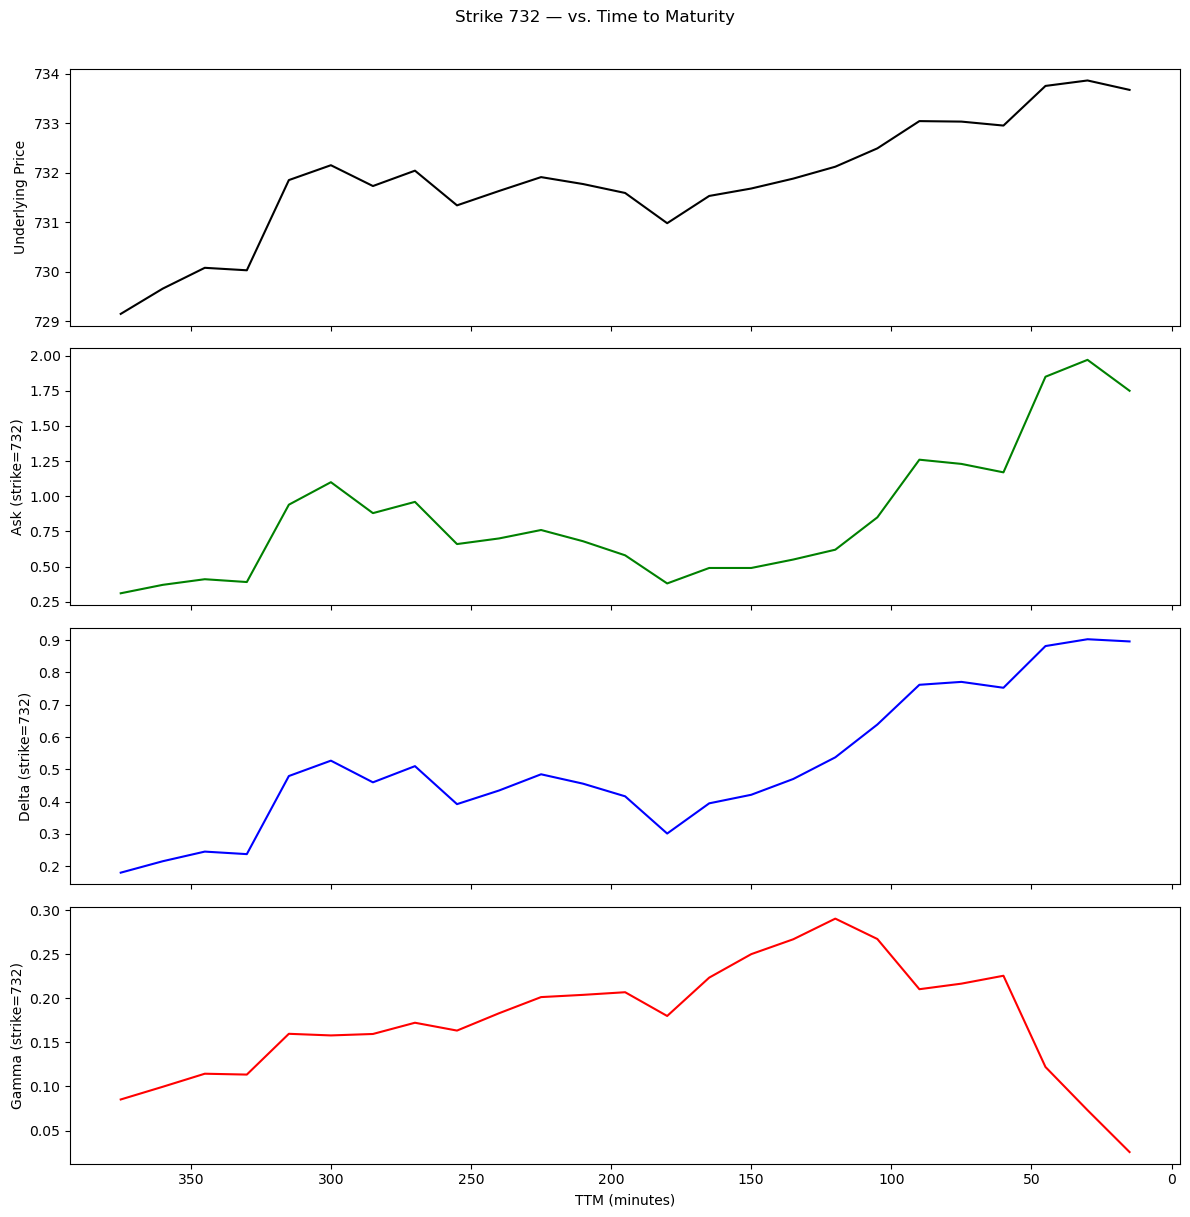

In [24]:
strike_df = df[df['strike'] == 732].sort_values('ttm_min', ascending=False)
underlying = df.drop_duplicates('ttm_min').sort_values('ttm_min', ascending=False)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(underlying['ttm_min'], underlying['underlying_price'], color='black')
axes[0].set_ylabel('Underlying Price')

axes[1].plot(strike_df['ttm_min'], strike_df['ask'], color='green')
axes[1].set_ylabel('Ask (strike=732)')

axes[2].plot(strike_df['ttm_min'], strike_df['delta'], color='blue')
axes[2].set_ylabel('Delta (strike=732)')

axes[3].plot(strike_df['ttm_min'], strike_df['gamma'], color='red')
axes[3].set_ylabel('Gamma (strike=732)')
axes[3].set_xlabel('TTM (minutes)')
axes[3].invert_xaxis()  # time flows left to right (high ttm → 0)

fig.suptitle('Strike 732 — vs. Time to Maturity', y=1.01)
plt.tight_layout()
plt.show()
